# **Topic Modelling using BERTopic - to find the most prevalent topics of bot vs. non-bot tweets**

### *Code for a comparison report on topic modelling results* 
#### Author: Naut Rafferty 
#### Student ID: 35245677

### **Overall Steps:**
- 'Twitter-Bot Detection Dataset' split by bot-label for separate modelling
- pre-processing, hyperparameter tuning & transformation applied to both datasets fairly
- BERTopic topic extraction clustering & topic reduction applied to both datasets
- cluster visualisation graphs plotted
- comparison graphs plotted for further analysis



## **----| Kaggle Environment Setup |----**
##### *not relevant to actual model*

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
import os

for dirname, _, filenames in os.walk('/data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/goyaladi/twitter-bot-detection-dataset/Readme.md
/kaggle/input/datasets/goyaladi/twitter-bot-detection-dataset/bot_detection_data.csv


## **----| Install Libraries and Imports |----**

In [ ]:
!pip install -q bertopic sentence-transformers

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sentence_transformers import SentenceTransformer #embedding model
import hdbscan #added for custom hyperparams
from umap import UMAP #added for custom hyperparams
from bertopic import BERTopic #uses inbuilt c-TF-IDF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 1.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
2026-05-13 08:24:33.295144: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778660673.554002      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778660673.629423      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778660674.245878      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778660674.245943      16 computation_placer.cc:177] computation placer al

## **----| Load & Split Dataset |----**
##### *display head info, then split into bot vs non-bot subsets*

In [ ]:
#load dataset from notebook input
DATA_PATH = "/kaggle/input/datasets/goyaladi/twitter-bot-detection-dataset/bot_detection_data.csv"

df = pd.read_csv(DATA_PATH)
print(df.columns)
df.head()

#split dataset into bot & non-bot using bot-label column data
TEXT_COL = "Tweet"
LABEL_COL = "Bot Label"

df = df.dropna(subset=[TEXT_COL, LABEL_COL])
bots_df = df[df[LABEL_COL] == 1].copy()
nonbots_df = df[df[LABEL_COL] == 0].copy()

#display number of tweets in each subset
print("Bot tweets:", len(bots_df))
print("Non-bot tweets:", len(nonbots_df))

Index(['User ID', 'Username', 'Tweet', 'Retweet Count', 'Mention Count',
       'Follower Count', 'Verified', 'Bot Label', 'Location', 'Created At',
       'Hashtags'],
      dtype='object')
Bot tweets: 25018
Non-bot tweets: 24982


## **----| Data Preprocessing |----**
##### *methods & tools includes:*
- stop word removal using sklearn
- cleaning - removing 'dirty' (empty) values

In [ ]:
stopwords = ENGLISH_STOP_WORDS

def clean_tweet(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text) #links
    text = re.sub(r"@\w+", " ", text)             #mentions
    text = re.sub(r"#", "", text)                 #hash symbol
    text = re.sub(r"\d+", " ", text)              #digits/numbers
    text = re.sub(r"[^a-z\s]", " ", text)         #double-check lowercase letters
    
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords and len(t) > 2]
    return " ".join(tokens)

bots_df["clean_text"] = bots_df[TEXT_COL].astype(str).apply(clean_tweet)
nonbots_df["clean_text"] = nonbots_df[TEXT_COL].astype(str).apply(clean_tweet)

#drop empty docs after cleaning
bots_df = bots_df[bots_df["clean_text"].str.strip().astype(bool)]
nonbots_df = nonbots_df[nonbots_df["clean_text"].str.strip().astype(bool)]

#display number of tweets in subsets after cleaning
print("After cleaning - Bot tweets:", len(bots_df))
print("After cleaning - Non-bot tweets:", len(nonbots_df))

After cleaning - Bot tweets: 25018
After cleaning - Non-bot tweets: 24981


## **----| BERTopic model embedding & Model Parameter tuning |----**
### BERTopic Model helper with UMAP & HDBSCAN instantiation
##### *methods & tools includes:*
- sklearn SentenceTransformer model combined with BERTopic transformer abilities
- custom UMAP - dimensionality reduction:
  - n-neighbors set to 30 for larger clusters
  - n-components set to 5 for dimension reduction
- default HDBSCAN within BERTopic - density-based clustering of topics
  - min-cluster-size increased for more global topic selection (default 10)
  - min-samples reduced to 1 for fewer outliers (default 10)

In [ ]:
#transformer - embedding of tweets into numerical vectors
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

def run_bertopic_for_subset(texts, subset_name):
    print(f"\n=== Running BERTopic for {subset_name} tweets ===")
 
    umap_model = UMAP(
        n_neighbors=30, 
        n_components=5,
        min_dist=0.1,
        metric='cosine',
        random_state=42
    )
    
    hdbscan_model = hdbscan.HDBSCAN(
        min_cluster_size=20, 
        min_samples=1,     
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )
    
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        calculate_probabilities=True,
        verbose=True
    )
 
    #pre-compute embeddings for reuse
    embeddings = embedding_model.encode(texts, show_progress_bar=True)
    topics, probs = topic_model.fit_transform(texts, embeddings=embeddings)
    topic_info = topic_model.get_topic_info()
 
    return topic_model, topics, probs, topic_info, embeddings

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## **----| Running BERTopic model on both datasets |----**
##### Uses the helper method defined above
##### Topic reduction necessary 150+ topics defined, limit of 80 as a sensible amount for dataset of 25k tweets each

In [ ]:
#convert to list for model
bot_texts    = bots_df["clean_text"].tolist()
nonbot_texts = nonbots_df["clean_text"].tolist()

#running BERTopic model helper function
bot_model,    bot_topics,    bot_probs,    bot_info,    bot_embeddings    = run_bertopic_for_subset(bot_texts,    "Bot")
nonbot_model, nonbot_topics, nonbot_probs, nonbot_info, nonbot_embeddings = run_bertopic_for_subset(nonbot_texts, "Non-bot")

#individual topic reduction - hard floor limit of 80 topics
bot_model.reduce_topics(bot_texts, nr_topics=80)
nonbot_model.reduce_topics(nonbot_texts, nr_topics=80)

#refresh topic info after reduction
bot_info    = bot_model.get_topic_info()
nonbot_info = nonbot_model.get_topic_info()


=== Running BERTopic for Bot tweets ===


Batches:   0%|          | 0/782 [00:00<?, ?it/s]

2026-05-13 08:30:05,012 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-13 08:30:49,244 - BERTopic - Dimensionality - Completed ✓
2026-05-13 08:30:49,247 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-13 08:31:23,400 - BERTopic - Cluster - Completed ✓
2026-05-13 08:31:23,415 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-13 08:31:23,607 - BERTopic - Representation - Completed ✓



=== Running BERTopic for Non-bot tweets ===


Batches:   0%|          | 0/781 [00:00<?, ?it/s]

2026-05-13 08:32:25,947 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-13 08:32:50,308 - BERTopic - Dimensionality - Completed ✓
2026-05-13 08:32:50,311 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-13 08:33:20,171 - BERTopic - Cluster - Completed ✓
2026-05-13 08:33:20,179 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-13 08:33:20,360 - BERTopic - Representation - Completed ✓
2026-05-13 08:33:20,822 - BERTopic - Topic reduction - Reducing number of topics
2026-05-13 08:33:20,858 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-13 08:33:21,012 - BERTopic - Representation - Completed ✓
2026-05-13 08:33:21,017 - BERTopic - Topic reduction - Reduced number of topics from 177 to 80
2026-05-13 08:33:21,348 - BERTopic - Topic reduction - Reducing number of topics
2026-05-13 08:33:21,383 - BERTopic - Representation - Fine-tuning topics using representation 

## **----| Topic Clustering Output Check & Visualisation |----**
##### *Inspection of the clustering quality using:*
- Top 5 topic summaries with outliers
- example topic data of the first topics (full document output)
- Top 5 words of the first topics
- Topic hierarchy plots
- Topic word scores for specific topics (bar charts)
- Scatter plots from document (word) level clustering

In [ ]:
#----output checking---- 
print("\n| Bot topic summary (top 5 + outliers) |")
display(bot_info.head(6))

print("\n| Non-bot topic summary (top 5 + outliers) |")
display(nonbot_info.head(6))

example_bot_topic    = bot_info[bot_info["Topic"]    != -1]["Topic"].iloc[0]
example_nonbot_topic = nonbot_info[nonbot_info["Topic"] != -1]["Topic"].iloc[0]

print(f"\n| Bot - top words for topic {example_bot_topic}: ")
print(bot_model.get_topic(example_bot_topic))

print(f"\n| Non-bot - top words for topic {example_nonbot_topic}: ")
print(nonbot_model.get_topic(example_nonbot_topic))

#----topic quality visualisation ---- 
#.show() does not render in Kaggle; write_html + display(HTML()) does.
def show_plotly(fig):
    display(HTML(fig.to_html(full_html=False, include_plotlyjs='cdn')))
    
#hierarchy plots
show_plotly(bot_model.visualize_hierarchy().update_layout(
    title="Bot Tweets - Topic Hierarchy"
))
show_plotly(nonbot_model.visualize_hierarchy().update_layout(
    title="Non-bot Tweets - Topic Hierarchy"
))

#top-word score bar charts
show_plotly(bot_model.visualize_barchart(
    topics=[example_bot_topic],
    title="Bot Tweets - Topic Word Scores",
    n_words=8,
    width=450,
    height=300
))
show_plotly(nonbot_model.visualize_barchart(
    topics=[example_nonbot_topic],
    title="Non-bot Tweets - Topic Word Scores",
    n_words=8,
    width=450,
    height=300
))
 
#document scatter (pre-computed embeddings used)
show_plotly(bot_model.visualize_documents(
    bot_texts, embeddings=bot_embeddings,
    title="Bot Tweets - Document & Topic Scatter"
))
show_plotly(nonbot_model.visualize_documents(
    nonbot_texts, embeddings=nonbot_embeddings,
    title="Non-bot Tweets - Document & Topic Scatter"
))
 


| Bot topic summary (top 5 + outliers) |


,Topic,Count,Name,Representation,Representative_Docs
0,-1,8943,-1_artist_draw_politics_wall,"[artist, draw, politics, wall, note, federal, ...",[beat carry especially night near standard fig...
1,0,844,0_radio_song_music_voice,"[radio, song, music, voice, speech, sound, sin...","[town finish radio, participant civil sound mu..."
2,1,724,1_marriage_husband_wife_relationship,"[marriage, husband, wife, relationship, woman,...",[citizen stock figure surface probably make ma...
3,2,644,2_father_daughter_parent_mother,"[father, daughter, parent, mother, child, son,...",[position purpose support career parent window...
4,3,568,3_capital_budget_economy_investment,"[capital, budget, economy, investment, financi...","[investment perform able live capital past, co..."
5,4,564,4_food_dinner_kitchen_eat,"[food, dinner, kitchen, eat, particular, natur...",[training food light need team hold dinner man...



| Non-bot topic summary (top 5 + outliers) |


,Topic,Count,Name,Representation,Representative_Docs
0,-1,9017,-1_garden_girl_family_baby,"[garden, girl, family, baby, woman, son, child...",[clear industry idea say minute deep nation ma...
1,0,961,0_music_song_sing_rock,"[music, song, sing, rock, sound, voice, speech...","[sing bag investment response song serve, smil..."
2,1,866,1_investment_claim_security_financial,"[investment, claim, security, financial, trade...",[investment trade trade president deep dinner ...
3,2,610,2_drug_hospital_medical_doctor,"[drug, hospital, medical, doctor, health, trea...",[event candidate drug short medical stop young...
4,3,542,3_month_spring_card_floor,"[month, spring, card, floor, table, week, rang...",[position design range reality month hope oper...
5,4,511,4_camera_painting_image_art,"[camera, painting, image, art, picture, artist...",[painting agent public film police camera data...



| Bot - top words for topic 0: 
[('radio', np.float64(0.0631062786875121)), ('song', np.float64(0.05485323370214026)), ('music', np.float64(0.05380179496958197)), ('voice', np.float64(0.03991634317640754)), ('speech', np.float64(0.030940873114693155)), ('sound', np.float64(0.028579935544197698)), ('sing', np.float64(0.018444933030639474)), ('listen', np.float64(0.014239493331198012)), ('speak', np.float64(0.007784534303764085)), ('site', np.float64(0.006509976363755108))]

| Non-bot - top words for topic 0: 
[('music', np.float64(0.06378242705221684)), ('song', np.float64(0.062158565542431085)), ('sing', np.float64(0.0391806581264455)), ('rock', np.float64(0.03913059165209655)), ('sound', np.float64(0.030533874095907524)), ('voice', np.float64(0.02809944515511222)), ('speech', np.float64(0.025523025863726553)), ('artist', np.float64(0.013582519416430208)), ('beat', np.float64(0.012990209498479805)), ('listen', np.float64(0.009260044426116526))]


## **----| Bot vs. Non-bot Visualisations & Comparison |----**
##### *Seperate & Combined visualisations for analysis includes:*
- separate topic frequency bar plots for each
- top 10 topic comparison tables 

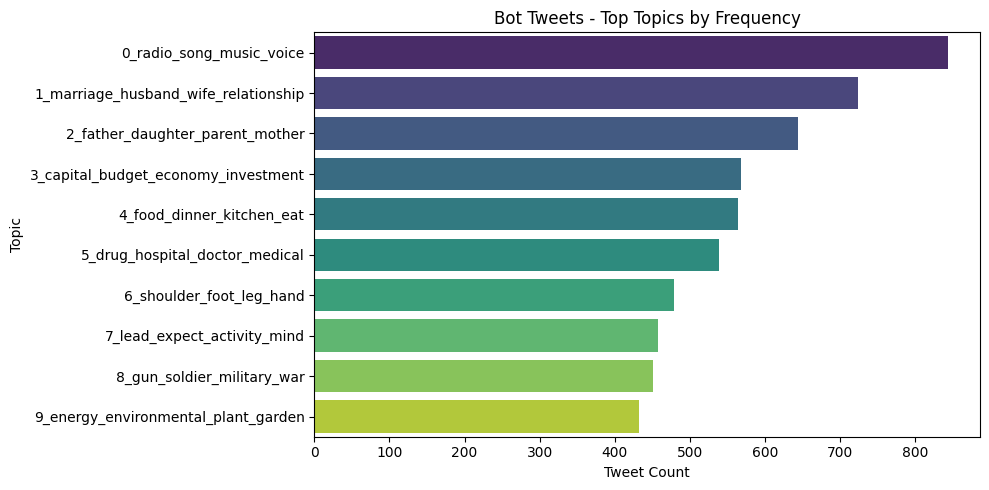

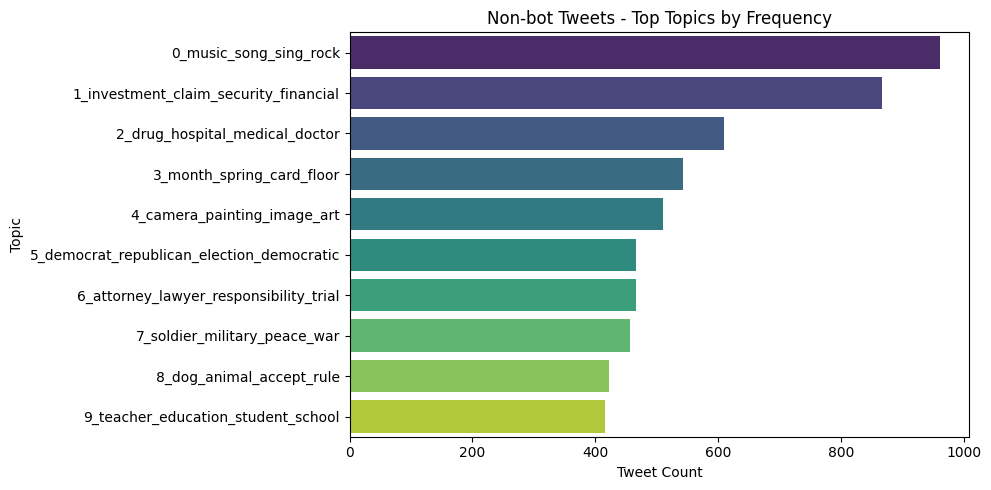


| Bot Tweets - Top 10 Topics |


,Topic,Name,Count,Group
1,0,0_radio_song_music_voice,844,Bot
2,1,1_marriage_husband_wife_relationship,724,Bot
3,2,2_father_daughter_parent_mother,644,Bot
4,3,3_capital_budget_economy_investment,568,Bot
5,4,4_food_dinner_kitchen_eat,564,Bot
6,5,5_drug_hospital_doctor_medical,539,Bot
7,6,6_shoulder_foot_leg_hand,479,Bot
8,7,7_lead_expect_activity_mind,457,Bot
9,8,8_gun_soldier_military_war,451,Bot
10,9,9_energy_environmental_plant_garden,432,Bot



| Non-bot Tweets - Top 10 Topics |


,Topic,Name,Count,Group
1,0,0_music_song_sing_rock,961,Non-bot
2,1,1_investment_claim_security_financial,866,Non-bot
3,2,2_drug_hospital_medical_doctor,610,Non-bot
4,3,3_month_spring_card_floor,542,Non-bot
5,4,4_camera_painting_image_art,511,Non-bot
6,5,5_democrat_republican_election_democratic,467,Non-bot
7,6,6_attorney_lawyer_responsibility_trial,466,Non-bot
8,7,7_soldier_military_peace_war,456,Non-bot
9,8,8_dog_animal_accept_rule,423,Non-bot
10,9,9_teacher_education_student_school,416,Non-bot


In [ ]:
#----separate plotting- frequency bar charts----
def plot_top_topics(topic_info, title, top_n=10):
    data = topic_info[topic_info["Topic"] != -1].head(top_n)
    plt.figure(figsize=(10, 5))
    sns.barplot(data=data, x="Count", y="Name", palette="viridis")
    plt.title(title)
    plt.xlabel("Tweet Count")
    plt.ylabel("Topic")
    plt.tight_layout()
    plt.show()

plot_top_topics(bot_info,    "Bot Tweets - Top Topics by Frequency")
plot_top_topics(nonbot_info, "Non-bot Tweets - Top Topics by Frequency")

#----combined top-topic tables----
def get_top_topic_counts(topic_info, label, top_n=10):
    t = topic_info[topic_info["Topic"] != -1].head(top_n).copy()
    t["Group"] = label
    return t[["Topic", "Name", "Count", "Group"]]

print("\n| Bot Tweets - Top 10 Topics |")
display(get_top_topic_counts(bot_info, "Bot"))

print("\n| Non-bot Tweets - Top 10 Topics |")
display(get_top_topic_counts(nonbot_info, "Non-bot"))